---
### 1. Khai báo 5 câu giao dịch người dùng ($s_1$ đến $s_5$)
* **$s_1$**: *"The user bought a wireless mouse and a mechanical keyboard."*
* **$s_2$**: *"The user bought a gaming laptop and a wireless mouse."*
* **$s_3$**: *"The user bought noise-canceling headphones and a smart watch."*
* **$s_4$**: *"The user bought a mechanical keyboard and an ergonomic chair."*
* **$s_5$**: *"The user bought a smart watch and a wireless charger."*

In [1]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Khai báo 5 câu giao dịch
corpus = {
    "s1": "The user bought a wireless mouse and a mechanical keyboard.",
    "s2": "The user bought a gaming laptop and a wireless mouse.",
    "s3": "The user bought noise-canceling headphones and a smart watch.",
    "s4": "The user bought a mechanical keyboard and an ergonomic chair.",
    "s5": "The user bought a smart watch and a wireless charger."
}

df_corpus = pd.DataFrame(list(corpus.items()), columns=["Sentence_ID", "Raw_Text"])
sentences = list(corpus.values())
sentence_ids = list(corpus.keys())
df_corpus

,Sentence_ID,Raw_Text
0,s1,The user bought a wireless mouse and a mechani...
1,s2,The user bought a gaming laptop and a wireless...
2,s3,The user bought noise-canceling headphones and...
3,s4,The user bought a mechanical keyboard and an e...
4,s5,The user bought a smart watch and a wireless c...


---
### 2. Tách từ (Tokenization), Đánh chỉ mục (Token IDs) và Tạo Tensor Batch ($B \times T$)

Theo Lecture 02 (Slide 15 – 19):
1. **Tokenizer**: Ánh xạ từng từ/từ phụ (subword) sang một số nguyên duy nhất: $f: V \rightarrow \{0, 1, \dots, |V|-1\}$.
2. **Padding ($0$)**: Đệm thêm các số 0 vào các câu ngắn để đưa toàn bộ batch về cùng độ dài $T$.
3. **Attention Mask ($M$)**: Vector nhị phân $M \in \{0, 1\}^T$ báo cho mô hình biết đâu là token thật ($1$) và đâu là token đệm ($0$).

In [2]:
# Tải mô hình Pretrained Transformer & Tokenizer
model_name = "sentence-transformers/all-MiniLM-L6-v2"
print(f"Đang tải mô hình: {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()  # Chuyển sang chế độ inference

# Tokenize và Padding toàn bộ batch 5 câu
encoded_inputs = tokenizer(
    sentences,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

input_ids = encoded_inputs["input_ids"]
attention_mask = encoded_inputs["attention_mask"]

B, T = input_ids.shape
print(f"\n✅ Kích thước Tensor Token IDs (B x T): {B} câu x {T} tokens")
print(f"   • Batch size (B): {B}")
print(f"   • Sequence length (T): {T} tokens\n")

print("=" * 80)
print("CHI TIẾT TOKEN HÓA VÀ TOKEN IDs TỪNG CÂU:")
print("=" * 80)
for i, sid in enumerate(sentence_ids):
    tokens = tokenizer.convert_ids_to_tokens(input_ids[i])
    ids = input_ids[i].tolist()
    mask = attention_mask[i].tolist()
    print(f"[{sid.upper()}]: \"{sentences[i]}\"")
    print(f"  • Tokens         : {tokens}")
    print(f"  • Token IDs      : {ids}")
    print(f"  • Attention Mask : {mask}\n")

Đang tải mô hình: sentence-transformers/all-MiniLM-L6-v2...


/opt/miniconda3/envs/myenv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(



✅ Kích thước Tensor Token IDs (B x T): 5 câu x 16 tokens
   • Batch size (B): 5
   • Sequence length (T): 16 tokens

CHI TIẾT TOKEN HÓA VÀ TOKEN IDs TỪNG CÂU:
[S1]: "The user bought a wireless mouse and a mechanical keyboard."
  • Tokens         : ['[CLS]', 'the', 'user', 'bought', 'a', 'wireless', 'mouse', 'and', 'a', 'mechanical', 'keyboard', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
  • Token IDs      : [101, 1996, 5310, 4149, 1037, 9949, 8000, 1998, 1037, 6228, 9019, 1012, 102, 0, 0, 0]
  • Attention Mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]

[S2]: "The user bought a gaming laptop and a wireless mouse."
  • Tokens         : ['[CLS]', 'the', 'user', 'bought', 'a', 'gaming', 'laptop', 'and', 'a', 'wireless', 'mouse', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
  • Token IDs      : [101, 1996, 5310, 4149, 1037, 10355, 12191, 1998, 1037, 9949, 8000, 1012, 102, 0, 0, 0]
  • Attention Mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]

[S3]: "The user bought noise-canceli

In [3]:
# Hiển thị Token IDs dưới dạng bảng ma trận B x T
df_token_ids = pd.DataFrame(
    input_ids.numpy(),
    index=sentence_ids,
    columns=[f"Pos_{j}" for j in range(T)]
)
print("MA TRẬN TOKEN IDs (Tensor X_id in N^(5 x T)):")
df_token_ids

MA TRẬN TOKEN IDs (Tensor X_id in N^(5 x T)):


,Pos_0,Pos_1,Pos_2,Pos_3,Pos_4,Pos_5,Pos_6,Pos_7,Pos_8,Pos_9,Pos_10,Pos_11,Pos_12,Pos_13,Pos_14,Pos_15
s1,101,1996,5310,4149,1037,9949,8000,1998,1037,6228,9019,1012,102,0,0,0
s2,101,1996,5310,4149,1037,10355,12191,1998,1037,9949,8000,1012,102,0,0,0
s3,101,1996,5310,4149,5005,1011,17542,2075,2132,19093,1998,1037,6047,3422,1012,102
s4,101,1996,5310,4149,1037,6228,9019,1998,2019,9413,7446,22026,3242,1012,102,0
s5,101,1996,5310,4149,1037,6047,3422,1998,1037,9949,3715,2099,1012,102,0,0


---
### 3. Trích xuất Tensor Nhúng Đa chiều $\mathcal{E} \in \mathbb{R}^{B \times T \times d}$ & Mean Pooling

1. **Tensor nhúng cấp độ Token (Token-level Embeddings)**:
   Mỗi token $t$ trong câu được ánh xạ qua các lớp Transformer thành 1 vector đặc trưng $d = 384$ chiều:
   $$\mathcal{E} \in \mathbb{R}^{B \times T \times d} = \mathbb{R}^{5 \times 15 \times 384}$$

2. **Mean Pooling (Gom cụm cấp độ câu)**:
   Để tạo ra 1 vector duy nhất đại diện cho toàn bộ câu, ta tính trung bình có trọng số theo Attention Mask:
   $$\mathbf{e}_{\text{sentence}} = \frac{\sum_{t=1}^T M_{t} \cdot \mathbf{e}_t}{\sum_{t=1}^T M_{t}} \in \mathbb{R}^d$$
   Sau đó chuẩn hóa $L_2$ để có vector đơn vị.

In [4]:
# Truyền tensor qua mô hình Pretrained Transformer
with torch.no_grad():
    model_output = model(**encoded_inputs)

# Lấy tensor tầng ẩn cuối cùng (Last Hidden State): B x T x d
token_embeddings = model_output.last_hidden_state
B, T, d = token_embeddings.shape
print(f"✅ Kích thước Tensor Nhúng Đa chiều (B x T x d): {B} x {T} x {d}")
print(f"   • B (Batch): {B} câu")
print(f"   • T (Tokens): {T} tokens mỗi câu")
print(f"   • d (Hidden Dimension): {d} chiều đặc trưng\n")

# Thực hiện Mean Pooling có tính đến Attention Mask
input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
sentence_embeddings = sum_embeddings / sum_mask

# Chuẩn hóa L2
sentence_embeddings_norm = F.normalize(sentence_embeddings, p=2, dim=1)

print(f"✅ Kích thước Ma trận Vector Nhúng Câu (Sentence Embeddings Matrix X): {sentence_embeddings_norm.shape} (5 câu x {d} chiều)")

✅ Kích thước Tensor Nhúng Đa chiều (B x T x d): 5 x 16 x 384
   • B (Batch): 5 câu
   • T (Tokens): 16 tokens mỗi câu
   • d (Hidden Dimension): 384 chiều đặc trưng

✅ Kích thước Ma trận Vector Nhúng Câu (Sentence Embeddings Matrix X): torch.Size([5, 384]) (5 câu x 384 chiều)


---
### 4. Ma trận Biểu diễn Nhúng Đặc trưng Dày đặc (Dense Feature Matrix $\mathbf{X} \in \mathbb{R}^{5 \times 384}$)
*(Hiển thị 12 chiều đầu tiên trong tổng số 384 chiều của mỗi câu)*

In [5]:
# Tạo DataFrame hiển thị các chiều đặc trưng
embed_np = sentence_embeddings_norm.numpy()
df_dense = pd.DataFrame(
    embed_np[:, :12],
    index=sentence_ids,
    columns=[f"Dim_{j+1}" for j in range(12)]
)
print("12 CHIỀU ĐẶC TRƯNG ĐẦU TIÊN CỦA MA TRẬN NHÚNG (X in R^(5 x 384)):")
df_dense.round(4)

12 CHIỀU ĐẶC TRƯNG ĐẦU TIÊN CỦA MA TRẬN NHÚNG (X in R^(5 x 384)):


,Dim_1,Dim_2,Dim_3,Dim_4,Dim_5,Dim_6,Dim_7,Dim_8,Dim_9,Dim_10,Dim_11,Dim_12
s1,-0.0485,0.0727,0.0341,-0.0667,-0.0449,-0.0028,0.1449,0.0709,-0.0545,0.0732,0.1624,0.0975
s2,-0.0168,0.1052,-0.0082,-0.0872,-0.0226,-0.0049,0.1432,0.0265,-0.0820,0.0629,0.1160,0.0856
s3,-0.0600,0.0792,0.0496,-0.0166,-0.0513,0.0210,0.1871,-0.0232,-0.0346,0.0173,0.1216,0.0762
s4,-0.0094,0.0588,0.0017,-0.0287,-0.0894,0.0177,0.1333,0.0663,0.0015,0.0380,0.1334,0.0552
s5,-0.0952,0.1351,0.0151,-0.0016,0.0012,0.0155,0.1078,0.0567,-0.0454,0.0233,0.1480,0.0624


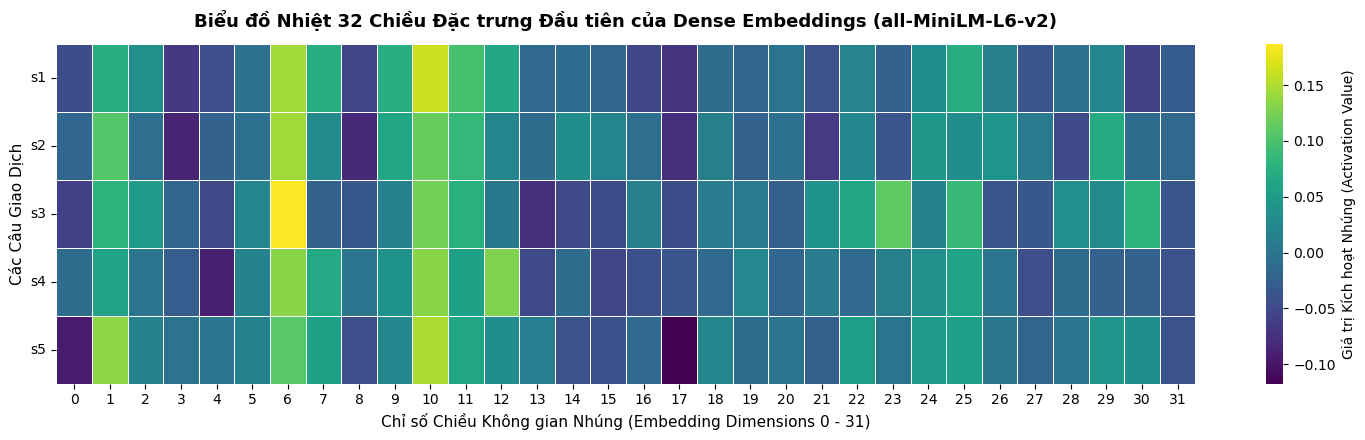

In [6]:
plt.figure(figsize=(15, 4.5))
sns.heatmap(
    embed_np[:, :32],
    annot=False,
    cmap="viridis",
    cbar_kws={"label": "Giá trị Kích hoạt Nhúng (Activation Value)"},
    linewidths=0.5
)
plt.title("Biểu đồ Nhiệt 32 Chiều Đặc trưng Đầu tiên của Dense Embeddings (all-MiniLM-L6-v2)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Chỉ số Chiều Không gian Nhúng (Embedding Dimensions 0 - 31)", fontsize=11)
plt.ylabel("Các Câu Giao Dịch", fontsize=11)
plt.yticks(ticks=np.arange(5) + 0.5, labels=sentence_ids, rotation=0)
plt.tight_layout()
plt.show()

---
### 5. Ma trận Tương đồng Ngữ nghĩa Sâu sắc (Semantic Cosine Similarity Matrix)

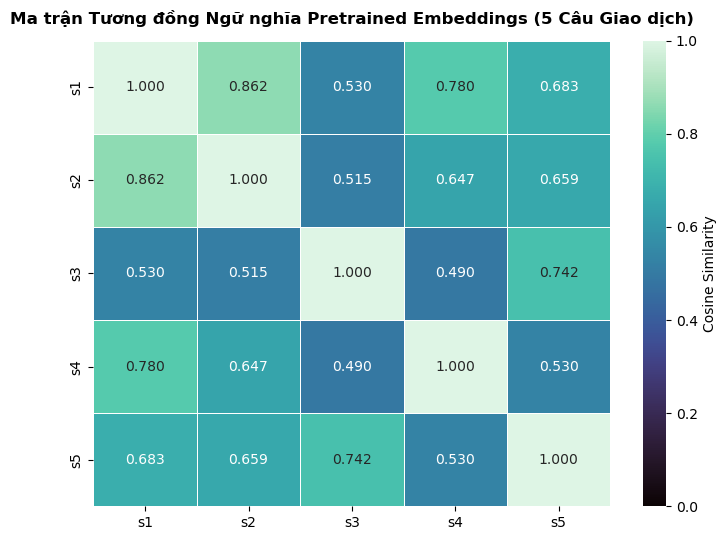


Phân tích Cụm Sở thích Khách hàng qua Pretrained Embeddings:
1. Nhóm Thiết bị Tin học / Văn phòng:
   • s1 (Mouse + Keyboard) & s2 (Laptop + Mouse)    : Độ tương đồng = 0.862
   • s1 (Mouse + Keyboard) & s4 (Keyboard + Chair)  : Độ tương đồng = 0.780
   • s2 (Laptop + Mouse) & s4 (Keyboard + Chair)    : Độ tương đồng = 0.647

2. Nhóm Thiết bị Đeo Thông minh / Phụ kiện:
   • s3 (Headphones + Smart watch) & s5 (Smart watch + Charger): Độ tương đồng = 0.742


In [7]:
# Tính Cosine Similarity giữa các vector nhúng dày đặc
sim_matrix_dense = cosine_similarity(embed_np)
df_sim_dense = pd.DataFrame(sim_matrix_dense, index=sentence_ids, columns=sentence_ids)

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    df_sim_dense,
    annot=True,
    fmt=".3f",
    cmap="mako",
    vmin=0, vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Cosine Similarity"}
)
plt.title("Ma trận Tương đồng Ngữ nghĩa Pretrained Embeddings (5 Câu Giao dịch)", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

print("\nPhân tích Cụm Sở thích Khách hàng qua Pretrained Embeddings:")
print("1. Nhóm Thiết bị Tin học / Văn phòng:")
print(f"   • s1 (Mouse + Keyboard) & s2 (Laptop + Mouse)    : Độ tương đồng = {sim_matrix_dense[0, 1]:.3f}")
print(f"   • s1 (Mouse + Keyboard) & s4 (Keyboard + Chair)  : Độ tương đồng = {sim_matrix_dense[0, 3]:.3f}")
print(f"   • s2 (Laptop + Mouse) & s4 (Keyboard + Chair)    : Độ tương đồng = {sim_matrix_dense[1, 3]:.3f}")
print("\n2. Nhóm Thiết bị Đeo Thông minh / Phụ kiện:")
print(f"   • s3 (Headphones + Smart watch) & s5 (Smart watch + Charger): Độ tương đồng = {sim_matrix_dense[2, 4]:.3f}")

---
### 6. Trực quan hóa Không gian Ngữ nghĩa 2D (PCA Projection)

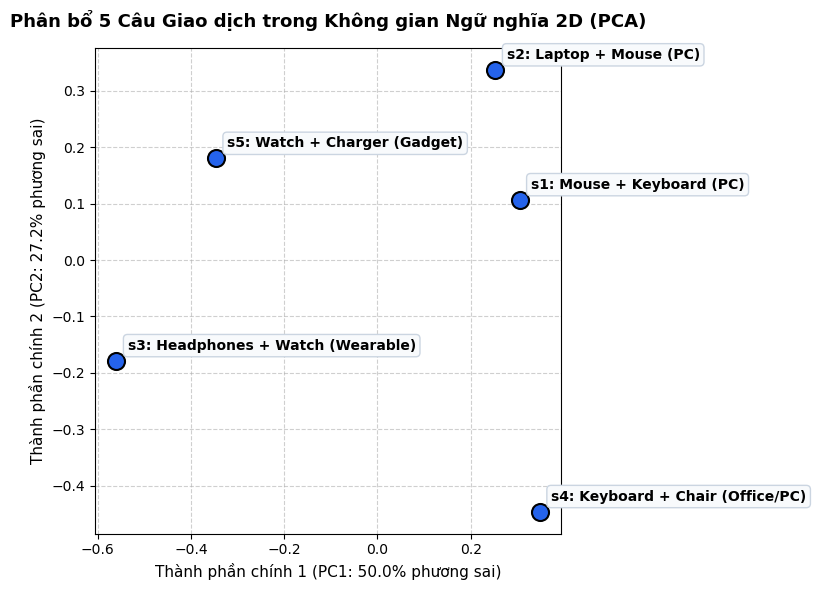

In [8]:
# Giảm chiều không gian từ 384D xuống 2D bằng PCA
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(embed_np)

plt.figure(figsize=(8, 6))
plt.scatter(coords_2d[:, 0], coords_2d[:, 1], color='#2563eb', s=150, zorder=3, edgecolors='black', linewidth=1.5)

labels = [
    "s1: Mouse + Keyboard (PC)",
    "s2: Laptop + Mouse (PC)",
    "s3: Headphones + Watch (Wearable)",
    "s4: Keyboard + Chair (Office/PC)",
    "s5: Watch + Charger (Gadget)"
]

for i, txt in enumerate(labels):
    plt.annotate(
        txt,
        (coords_2d[i, 0], coords_2d[i, 1]),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="#f8fafc", ec="#cbd5e1", lw=1)
    )

plt.title("Phân bổ 5 Câu Giao dịch trong Không gian Ngữ nghĩa 2D (PCA)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel(f"Thành phần chính 1 (PC1: {pca.explained_variance_ratio_[0]*100:.1f}% phương sai)", fontsize=11)
plt.ylabel(f"Thành phần chính 2 (PC2: {pca.explained_variance_ratio_[1]*100:.1f}% phương sai)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
### 7. So sánh Tổng hợp: TF-IDF (Sparse) vs. Pre-trained Embeddings (Dense)

| Tiêu chí | TF-IDF (Sparse Representation) | Pre-trained Embeddings (Dense Representation) |
| :--- | :--- | :--- |
| **Bản chất biểu diễn** | Vector thưa (Sparse Vector, nhiều số 0) | Vector dày đặc (Dense Vector, chứa thông tin ở mọi chiều) |
| **Kích thước chiều ($d$)** | Phụ thuộc số từ vựng trong tập dữ liệu ($d = 16$) | Cố định theo kiến trúc mô hình ($d = 384$) |
| **Dạng Tensor theo Lecture 02** | $\mathbf{X} \in \mathbb{R}^{B \times d}$ | $\mathcal{X}_{id} \in \mathbb{N}^{B \times T}$, $\mathcal{E} \in \mathbb{R}^{B \times T \times d}$, $\mathbf{X} \in \mathbb{R}^{B \times d}$ |
| **Hiểu ngữ cảnh & Từ đồng nghĩa** | **Không** (Chỉ khớp đúng từ giống nhau ký tự) | **Rất tốt** (Hiểu *"laptop"* và *"mouse"* cùng thuộc nhóm máy tính) |
| **Xử lý từ mới (OOV)** | Kém (Bỏ qua từ không có trong từ vựng) | Rất tốt (Sử dụng Subword Tokenization) |
| **Tốc độ & Tài nguyên** | Cực nhanh, tiêu tốn rất ít CPU/RAM | Yêu cầu mô hình Transformer, tài nguyên tính toán cao hơn |